# Linear Regression

### What are we trying to predict?
##### Let's use a very simple example first.
##### Suppose we want to predict:
> ##### App rating based on Number of reviews

In [1]:
# We have
# Reviews --> input
# Rating --> output
# X --> Reviews
# y --> Rating

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/processed/cleaned_googleplaystore.csv')

In [4]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,2544,Facebook,social,4.1,78158306.0,12.0,1000000000,free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,381,WhatsApp Messenger,communication,4.4,69119316.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,2604,Instagram,social,4.5,66577446.0,12.0,1000000000,free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,382,Messenger – Text and Video Chat for Free,communication,4.0,56646578.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,1879,Clash of Clans,game,4.6,44893888.0,98.0,100000000,free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


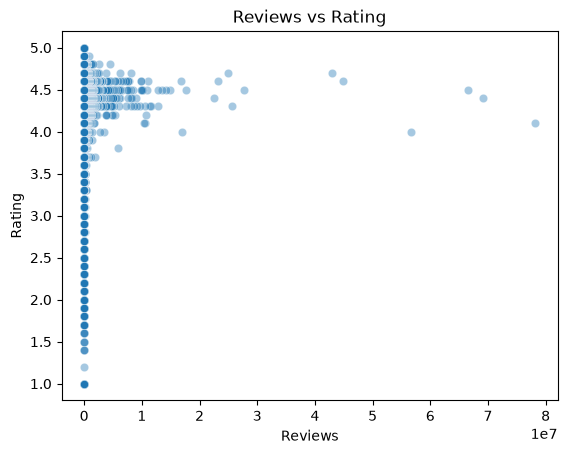

In [5]:
# First let's see the relationship between the reviews and the ratings. We can do this by plotting a scatter plot of the reviews against the ratings.
sns.scatterplot(
    data=df,
    x="Reviews",
    y="Rating",
    alpha=0.4
)

plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")

plt.show()

In [6]:
import numpy as np
x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 5, 4, 6])

In [7]:
import sklearn as sk

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
model = LinearRegression()

In [10]:
model.fit(
    x.reshape(-1, 1),
    y
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.8]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [11]:
model.coef_

array([0.8])

In [12]:
model.intercept_

np.float64(1.7999999999999998)

In [13]:
# prediction
predictions = model.predict(
    x.reshape(-1, 1)
)

In [14]:
print(predictions)

[2.6 3.4 4.2 5.  5.8]


In [15]:
# actual vs predicted
comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,2,2.6
1,4,3.4
2,5,4.2
3,4,5.0
4,6,5.8


In [16]:
# residual
residuals = y - predictions

In [17]:
comparison["Residual"] = residuals

comparison

,Actual,Predicted,Residual
0,2,2.6,-0.6
1,4,3.4,0.6
2,5,4.2,0.8
3,4,5.0,-1.0
4,6,5.8,0.2


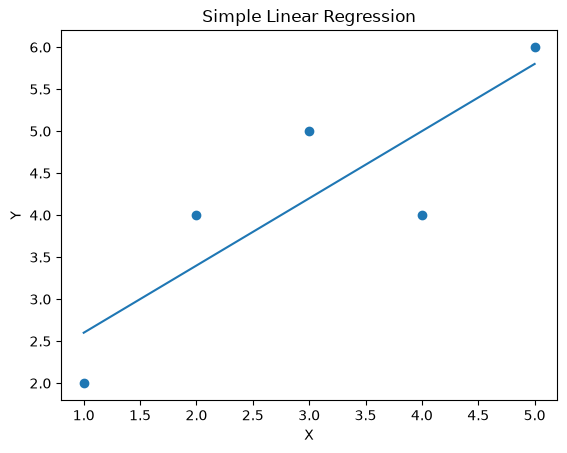

In [18]:
# plotting the regression line
plt.scatter(x, y)

plt.plot(
    x,
    predictions
)

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Simple Linear Regression")

plt.show()

In [19]:
# let's move to google play store data and see if we can predict the rating based on the number of reviews. We will use the same model as above.

#Feature → log_reviews
#Target → Rating

df["log_reviews"] = np.log1p(df["Reviews"])

In [20]:
model_df = df[
    ["log_reviews", "Rating"]
].dropna()

In [21]:
X = model_df["log_reviews"].values.reshape(-1, 1)
y = model_df["Rating"]

In [22]:
X

array([[18.1742469 ],
       [18.0513448 ],
       [18.01387644],
       ...,
       [ 0.        ],
       [ 0.        ],
       [ 0.        ]], shape=(9659, 1))

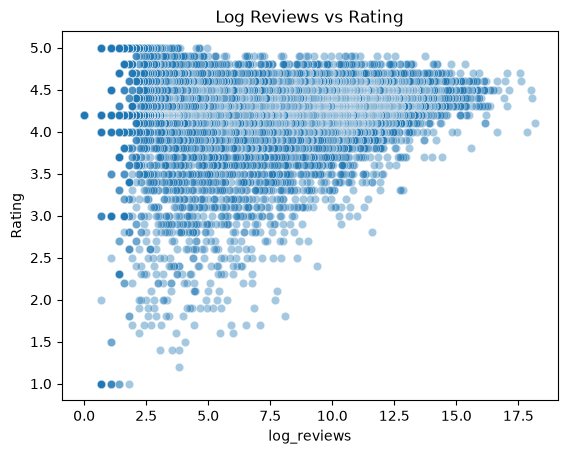

In [23]:
# visualizing the relationship between the log of reviews and the rating
sns.scatterplot(
    data=model_df,
    x="log_reviews",
    y="Rating",
    alpha=0.4
)

plt.title("Log Reviews vs Rating")

plt.show()

In [24]:
# Train and split
# perform the split

from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.02]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.062
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[367.46]


In [27]:
model.coef_

array([0.01713493])

In [28]:
model.intercept_

np.float64(4.062127160838411)

In [29]:
y_pred = model.predict(X_test)

### Evaluating the model
##### 1) MAE ---> $\frac{1}{n}\sum|y_i - \^y_i|$


In [30]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.3377040215127806


#### 2) MSE = $\frac{1}{n}\sum (y_i - \^y_i)^2$

In [31]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.2505065134687988


#### 3) RMSE = $\sqrt{MSE}$

In [32]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.5005062571724741


#### 4) Coefficient of Determination $R^2 = 1 - \frac{SS_{res}}{SS_{total}}$
#### $SS_{res} = \sum (y_i - \^y_i)^2$
#### $SS_{tot} = \sum (y_i - \=y)^2$

In [33]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: 0.011202125873231883


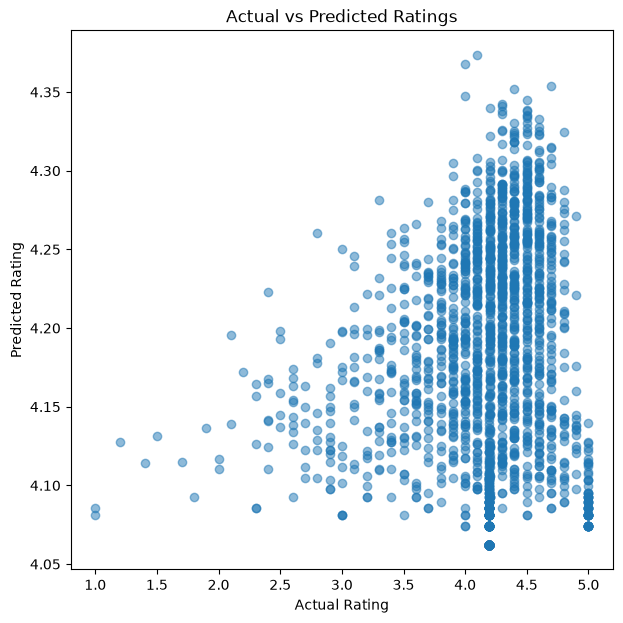

In [34]:
# plotting actual VS predicted
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.show()

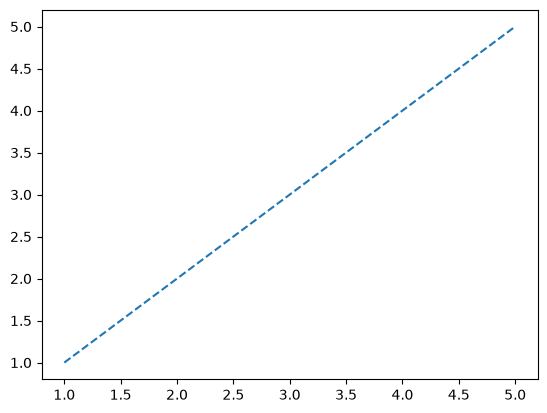

In [35]:
# adding a reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

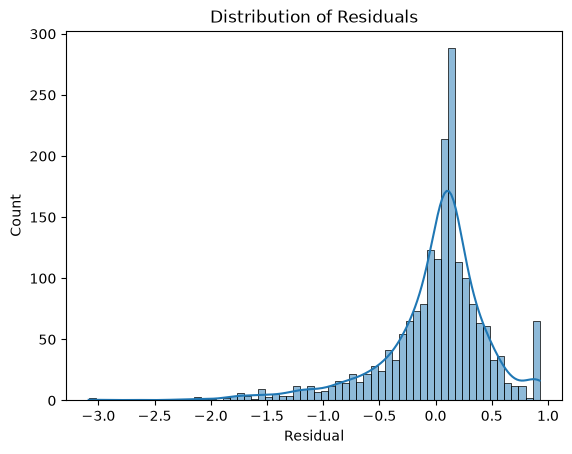

In [36]:
# residual analysis
residuals = y_test - y_pred

# plot
sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

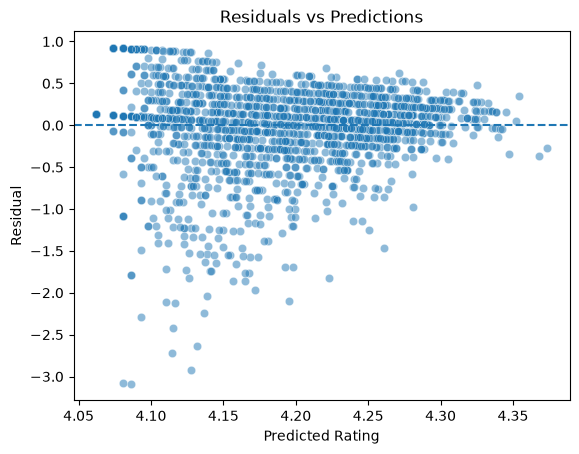

In [37]:
sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Residual")

plt.title("Residuals vs Predictions")

plt.show()

In [38]:
# predicting for a new app
new_reviews = 50000
new_reviews = np.log1p(new_reviews)
model.predict([[new_reviews]])

array([4.24752363])